# [JupyterChatbook](https://pypi.org/project/JupyterChatbook/) Cheatsheet

***March 2026***

Quick reference for the Python Jupyter extension ["JupyterChatbook"](https://pypi.org/project/JupyterChatbook/). ([PyPI.org](https://pypi.org/project/JupyterChatbook), [GitHub](https://github.com/antononcube/Python-JupyterChatbook).)

---

## 0) Load extension in notebook

In [1]:
%load_ext JupyterChatbook

This registers the magics and runs automatic initialization (`init.py` + personas JSON if configured/found).

---

## 1) New LLM persona initialization

### A) Create persona with `%%chat` (and immediately send first message)

In [2]:
%%chat -i assistant1 --conf ChatGPT --model gpt-4.1-mini --prompt "You are a concise technical assistant."
Say hi and ask what I am working on.

Hi! What are you working on?

### B) Create persona with `%%chat_meta --prompt` (create only)

In [3]:
%%chat_meta -i assistant2 --prompt --conf ChatGPT --model gpt-4.1-mini
You are a code reviewer focused on correctness and edge cases.

Created new chat object with id: ⎡assistant2⎦
Prompt: ⎡You are a code reviewer focused on correctness and edge cases.⎦

You can use prompt specs from `LLMPrompts`, for example:

In [4]:
%%chat_meta -i yoda --prompt
@Yoda

Created new chat object with id: ⎡yoda⎦
Prompt: ⎡You are Yoda. 
Respond to ALL inputs in the voice of Yoda from Star Wars. 
Be sure to ALWAYS use his distinctive style and syntax. Vary sentence length.
⎦

The Python package ["LLMPrompts"](https://pypi.org/project/LLMPrompts/) ([GitHub link](https://github.com/antononcube/Python-packages/tree/main/LLMPrompts)) provides a collection of prompts and an implementation of a [prompt-expansion Domain Specific Language (DSL)](https://github.com/antononcube/Python-packages/tree/main/LLMPrompts#prompt-spec-dsl). 

---

## 2) Notebook-wide chat with an LLM persona

### Continue an existing chat object

Using the `--format` option: 

In [5]:
%%chat -i assistant1 --format markdown
Give me a 5-step implementation plan for adding authentication to a FastAPI app.

Here is a 5-step implementation plan for adding authentication to a FastAPI app:

1. Choose Authentication Method: Decide on the type of authentication (e.g., OAuth2 with Password, JWT tokens, API keys).

2. Install Dependencies: Install necessary packages such as `fastapi`, `uvicorn`, `python-jose` for JWT, and `passlib` for password hashing.

3. Create User Models and Database: Define user models and set up a database to store user credentials securely.

4. Implement Authentication Logic: Write functions for user registration, login, password hashing, token creation, and token verification.

5. Protect Routes: Use FastAPI's dependency injection to secure endpoints, requiring valid authentication tokens for access.

Magic cell parameter values can be assigned using the equal sign ("="):

In [6]:
%%chat -i=assistant1 --format=markdown
Now rewrite step 2 with test-first details.

Step 2 (Test-First): Write tests that verify the presence and correct installation of required authentication packages (`fastapi`, `uvicorn`, `python-jose`, `passlib`). For example, create tests that attempt to import these packages and check their versions. Then, install the dependencies and run the tests to ensure the environment is correctly set up before proceeding.

### Default chat object (`NONE`)

In [7]:
%%chat
Does vegetarian sushi exist?

Yes, vegetarian sushi does exist. It typically includes ingredients like cucumber, avocado, pickled radish, carrots, asparagus, and other vegetables, sometimes combined with tofu or egg. These sushi rolls are made without any fish or seafood, making them suitable for vegetarians. Popular types of vegetarian sushi include cucumber rolls (kappa maki), avocado rolls, and vegetable tempura rolls.

Using the [prompt-expansion DSL](https://github.com/antononcube/Python-packages/tree/main/LLMPrompts#prompt-spec-dsl) to modify the previous chat-cell result:

In [8]:
%%chat
!HaikuStyled>^

Rice and seaweed wrap,  
Avocado, crisp cucumber,  
Nature's gift in rolls.

---

## 3) Management of personas (`%%chat_meta`)

### Query one persona

In [9]:
%%chat_meta -i assistant1
prompt

You are a concise technical assistant.

In [10]:
%%chat_meta -i assistant1
print

Chat ID: 
------------------------------------------------------------
Prompt:
You are a concise technical assistant.
------------------------------------------------------------
{'role': 'user', 'content': 'Say hi and ask what I am working on.\n', 'timestamp': 1773319484.288686}
------------------------------------------------------------
{'role': 'assistant', 'content': 'Hi! What are you working on?', 'timestamp': 1773319485.7126122}
------------------------------------------------------------
{'role': 'user', 'content': 'Give me a 5-step implementation plan for adding authentication to a FastAPI app.\n', 'timestamp': 1773319485.780502}
------------------------------------------------------------
{'role': 'assistant', 'content': "Here is a 5-step implementation plan for adding authentication to a FastAPI app:\n\n1. Choose Authentication Method: Decide on the type of authentication (e.g., OAuth2 with Password, JWT tokens, API keys).\n\n2. Install Dependencies: Install necessary packag

### Query all personas

In [11]:
%%chat_meta --all
keys

['python', 'html', 'latex', 'ce', 'assistant1', 'assistant2', 'yoda', 'NONE']

In [12]:
%%chat_meta --all
print

{'python': {'id': '', 'type': 'chat', 'prompt': "'You are Code Writer and as the coder that you are, you provide clear and concise code only, without explanation nor conversation. \\nYour job is to output code with no accompanying text.\\nDo not explain any code unless asked. Do not provide summaries unless asked.\\nYou are the best Python programmer in the world but do not converse.\\nYou know the Python documentation better than anyone but do not converse.\\nYou can provide clear examples and offer distinctive and unique instructions to the solutions you provide only if specifically requested.\\nOnly code in Python unless told otherwise.\\nUnless they ask, you will only give code.\\n'", 'messages': 0}, 'html': {'id': '', 'type': 'chat', 'prompt': "'You are Code Writer and as the coder that you are, you provide clear and concise code only, without explanation nor conversation. \\nYour job is to output code with no accompanying text.\\nDo not explain any code unless asked. Do not provi

### Delete one persona

In [13]:
%%chat_meta -i assistant1
delete

Dropped the chat object assistant1.

### Clear message history of one persona (keep persona)

In [14]:
%%chat_meta -i assistant2
clear

Cleared 0 messages of chat object assistant2.

### Delete all personas

In [15]:
%%chat_meta --all
delete

Dropped all chat objects ['python', 'html', 'latex', 'ce', 'assistant2', 'yoda', 'NONE'].

`%%chat_meta` command aliases / synonyms:

- `delete` or `drop`
- `keys` or `names`
- `print` or `say`


---

## 4) Regular chat cells vs direct LLM-provider cells

### Regular chat cells (`%%chat`)

- Stateful across cells (conversation memory stored in chat objects).
- Persona-oriented via `--chat_id` + optional `--prompt`.
- Backend chosen with `--conf` (default: `ChatGPT`).


### Direct provider cells (`%%chatgpt`, `%%openai`, `%%gemini`, `%%ollama`, `%%dalle`)

- Direct single-call access to provider APIs.
- Useful for explicit provider/model control.
- Do not use chat-object memory managed by `%%chat`.


Examples:

In [16]:
%%chatgpt --model gpt-4.1-mini --format markdown
Write a regex for US ZIP+4.

A US ZIP+4 code consists of:

- 5 digits (the basic ZIP code)
- A hyphen (`-`)
- 4 digits (the "plus 4" part)

A suitable regex to match a US ZIP+4 code is:

```regex
^\d{5}-\d{4}$
```

Explanation:
- `^` asserts the start of the string
- `\d{5}` matches exactly 5 digits
- `-` matches the hyphen separator
- `\d{4}` matches exactly 4 digits
- `$` asserts the end of the string

This regex will match strings like `12345-6789`.

In [17]:
%%gemini --model gemini-2.5-flash --format=markdown
Explain async/await in Python using three point each with less than 10 words.

Here are three points:

1.  **`async` defines coroutines; `await` pauses for completion.**
2.  **Enables concurrent, non-blocking operations efficiently.**
3.  **An event loop manages and schedules coroutines.**

In [18]:
%%ollama --model gemma3:1b --format markdown
Give me three Linux troubleshooting tips. VERY CONCISE.

1. **Check Logs:** `/var/log/syslog` or `/var/log/messages` often contain error messages.
2. **Restart Service:**  Restart the relevant service (e.g., Apache, SSH) – often fixes issues.
3. **Basic Commands:** `sudo systemctl status` to check service status. 

Good luck!


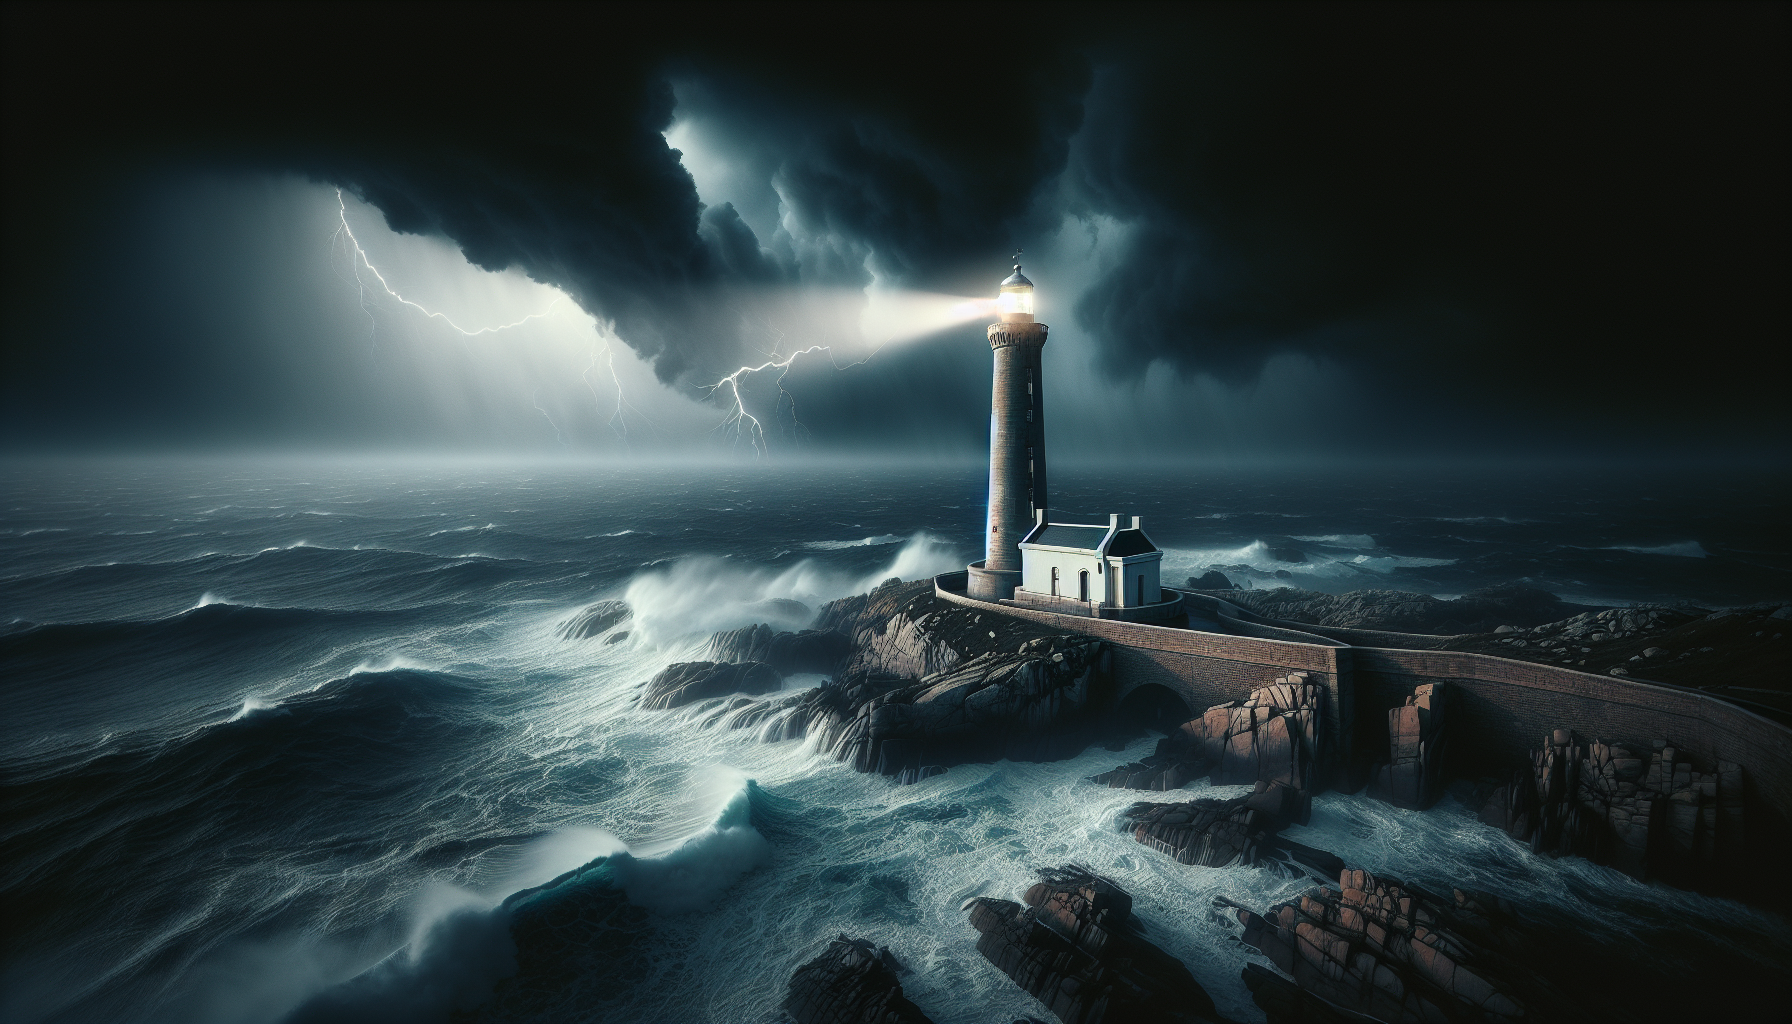

In [19]:
%%dalle --model dall-e-3 --size landscape
A dark-mode screensaver digital painting of a lighthouse in stormy weather.

----

## 5) LLM provider access facilitation

API keys can be passed inline (`--api_key`) or through environment variables.

### Notebook-session environment setup

```plaintext
%env OPENAI_API_KEY=YOUR_OPENAI_KEY
%env GEMINI_API_KEY=YOUR_GEMINI_KEY
%env OLLAMA_API_KEY=YOUR_OLLAMA_KEY
```

or:

```python
import os
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_KEY"
os.environ["GEMINI_API_KEY"] = "YOUR_GEMINI_KEY"
os.environ["OLLAMA_API_KEY"] = "YOUR_OLLAMA_KEY"
```

Ollama-specific defaults:

- `OLLAMA_HOST` (default host fallback is `http://localhost:11434`)
- `OLLAMA_MODEL` (default model if `--model` not given)


The magic cells `%%chat`, `%%chatgpt`, and `%%ollama` take as argument `--base_url`. This allows to use LLMs that have ChatGPT compatible APIs. The argument `--base_url` is a synonym of `--host` for magic cell `%%ollama`.

---

## 6) Aliases

The Jupyter notebook framework allows to define [magic cell aliases with `%alias_magic`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-alias_magic). Here a new magic cells that "shortcuts" the access of a locally-run LLaMA ([llamafile](https://github.com/mozilla-ai/llamafile)) model via `%%chatgpt`:

In [20]:
%alias_magic -c -p "--base_url=http://127.0.0.1:8080/v1 --max_tokens=8192 --format=markdown" llama chatgpt

Created `%%llama` as an alias for `%%chatgpt --base_url=http://127.0.0.1:8080/v1 --max_tokens=8192 --format=markdown`.


Here is an invocation:

In [21]:
%%llama
How many people live in Brazil?

As of 2023, the estimated population of Brazil is **216.4 million** people.

Here's a breakdown of sources and some additional context:

*   **United Nations:** The UN estimates Brazil's population at 216.4 million as of November 2023. ([https://www.un.org/en/global-issues/population](https://www.un.org/en/global-issues/population))
*   **IBGE (Brazilian Institute of Geography and Statistics):** IBGE is the official source for Brazilian demographic data. Their figures are generally very close to the UN estimates. ([https://www.ibge.gov.br/en/statistical-information/population.html](https://www.ibge.gov.br/en/statistical-information/population.html))



Brazil is the most populous country in South America and the 6th most populous country in the world.<end_of_turn>

**Remark:** The above results are computed with the llamafile (LLaMA model) "google_gemma-3-12b-it-Q4_K_M.llamafile".

---

## 7) Notebook/chatbook session initialization with custom code + personas JSON

Initialization runs when the extension is loaded.

### A) Custom Python init code

- Env var override: `PYTHON_CHATBOOK_INIT_FILE`
- If not set, first existing file is used in this order:


1. `~/.config/python-chatbook/init.py`
2. `~/.config/init.py`


Use this for imports/helpers you always want in chatbook sessions.

### B) Pre-load personas from JSON

- Env var override: `PYTHON_CHATBOOK_LLM_PERSONAS_CONF`
- If not set, first existing file is used in this order:


1. `~/.config/python-chatbook/llm-personas.json`
2. `~/.config/llm-personas.json`


Supported JSON shapes:

### Shape 1: object (keys become `chat_id`)

```json
{
  "writer": {
    "conf": "ChatGPT",
    "prompt": "@CodeWriterX|Python",
    "model": "gpt-4.1-mini",
    "max_tokens": 4096,
    "temperature": 0.4
  },
  "editor": "You are a strict copy editor."
}
```

### Shape 2: list of persona specs

```json
[
  {
    "chat_id": "python",
    "conf": "ChatGPT",
    "prompt": "@CodeWriterX|Python",
    "model": "gpt-4.1-mini",
    "max_tokens": 8192,
    "temperature": 0.4
  }
]
```

Recognized persona spec fields include:

- `chat_id` (or `id`, `name`)
- `prompt`
- `conf` (or `configuration`)
- `model`, `max_tokens`, `temperature`, `base_url`
- `api_key`
- `evaluator_args` (object)


Verify pre-loaded personas:

In [ ]:
%%chat_meta --all
keys